<a href="https://colab.research.google.com/github/Lio72rga/Miner-a-de-Datos-2026/blob/main/AO1_Clase2_Martinez_Lionel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# =========================================
# MINERÍA DE DATOS - CLASE 2
# Limpieza, Transformación y EDA
# Autor: Lionel Martinez, con asistencia de IA, en lineas de codigos.
# =========================================


In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder
import matplotlib.pyplot as plt



# =============================
# 2. CREAR DATASET
# =============================


In [2]:
df = pd.DataFrame({
    "ID": [1, 2, 3, 4, 5],
    "Nombre": ["Juan", "María", "Pedro", "Ana", "Luis"],
    "Edad": [32, -28, 40, 35, 50],
    "Nivel_Educativo": ["Licenciado", "Ingeniero", "Doctorado", "Licenciado", "Doctorado"],
    "Salario": [50000, 60000, None, 55000, 200000],
    "Categoria": ["Junior", "Senior", "Senior", "Junior", "Manager"],
    "Estado": ["Activo", "ACTIVO", "Inactivo", "Activo", "Inactivo"]
})

print("\nDATASET ORIGINAL:\n")
print(df)




DATASET ORIGINAL:

   ID Nombre  Edad Nivel_Educativo   Salario Categoria    Estado
0   1   Juan    32      Licenciado   50000.0    Junior    Activo
1   2  María   -28       Ingeniero   60000.0    Senior    ACTIVO
2   3  Pedro    40       Doctorado       NaN    Senior  Inactivo
3   4    Ana    35      Licenciado   55000.0    Junior    Activo
4   5   Luis    50       Doctorado  200000.0   Manager  Inactivo


# =============================
# 3. TIPOS DE DATOS
# =============================


In [3]:
print("\nTIPOS DE DATOS:\n")
print(df.dtypes)



TIPOS DE DATOS:

ID                   int64
Nombre              object
Edad                 int64
Nivel_Educativo     object
Salario            float64
Categoria           object
Estado              object
dtype: object


# =============================
# 4. LIMPIEZA DE DATOS
# =============================


In [4]:
# 4.2 Valores faltantes (Salario)
df["Salario"].fillna(df["Salario"].median(), inplace=True)

# 4.3 Normalizar texto (Estado)
df["Estado"] = df["Estado"].str.capitalize()

# 4.4 Detectar outliers con IQR
Q1 = df["Salario"].quantile(0.25)
Q3 = df["Salario"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Filtrar outliers
df = df[(df["Salario"] >= limite_inferior) & (df["Salario"] <= limite_superior)]

print("\nDATASET LIMPIO:\n")
print(df)

# =============================
# 5. TRANSFORMACIÓN DE DATOS
# =============================

# 5.1 Codificación ordinal (Nivel Educativo)
orden = [["Licenciado", "Ingeniero", "Doctorado"]]
encoder = OrdinalEncoder(categories=orden)
df["Nivel_Cod"] = encoder.fit_transform(df[["Nivel_Educativo"]])

# 5.2 Normalización de salario
scaler = MinMaxScaler()
df["Salario_Normalizado"] = scaler.fit_transform(df[["Salario"]])

# 5.3 Nueva variable
df["Años_Hasta_Jubilacion"] = 65 - df["Edad"]

print("\nDATASET TRANSFORMADO:\n")
print(df)



DATASET LIMPIO:

   ID Nombre  Edad Nivel_Educativo  Salario Categoria    Estado
0   1   Juan    32      Licenciado  50000.0    Junior    Activo
1   2  María   -28       Ingeniero  60000.0    Senior    Activo
2   3  Pedro    40       Doctorado  57500.0    Senior  Inactivo
3   4    Ana    35      Licenciado  55000.0    Junior    Activo

DATASET TRANSFORMADO:

   ID Nombre  Edad Nivel_Educativo  Salario Categoria    Estado  Nivel_Cod  \
0   1   Juan    32      Licenciado  50000.0    Junior    Activo        0.0   
1   2  María   -28       Ingeniero  60000.0    Senior    Activo        1.0   
2   3  Pedro    40       Doctorado  57500.0    Senior  Inactivo        2.0   
3   4    Ana    35      Licenciado  55000.0    Junior    Activo        0.0   

   Salario_Normalizado  Años_Hasta_Jubilacion  
0                 0.00                     33  
1                 1.00                     93  
2                 0.75                     25  
3                 0.50                     30  


/tmp/ipykernel_32613/1718374521.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Salario"].fillna(df["Salario"].median(), inplace=True)


# =============================
# 6. ANÁLISIS EXPLORATORIO (EDA)
# =============================


In [5]:
print("\nESTADÍSTICAS DESCRIPTIVAS:\n")
print(df.describe())



ESTADÍSTICAS DESCRIPTIVAS:

             ID       Edad       Salario  Nivel_Cod  Salario_Normalizado  \
count  4.000000   4.000000      4.000000   4.000000             4.000000   
mean   2.500000  19.750000  55625.000000   0.750000             0.562500   
std    1.290994  32.003906   4269.562819   0.957427             0.426956   
min    1.000000 -28.000000  50000.000000   0.000000             0.000000   
25%    1.750000  17.000000  53750.000000   0.000000             0.375000   
50%    2.500000  33.500000  56250.000000   0.500000             0.625000   
75%    3.250000  36.250000  58125.000000   1.250000             0.812500   
max    4.000000  40.000000  60000.000000   2.000000             1.000000   

       Años_Hasta_Jubilacion  
count               4.000000  
mean               45.250000  
std                32.003906  
min                25.000000  
25%                28.750000  
50%                31.500000  
75%                48.000000  
max                93.000000  


# =============================
# 7. VISUALIZACIONES
# =============================


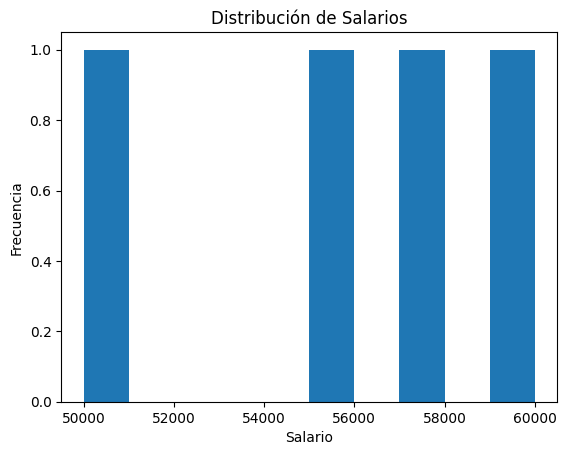

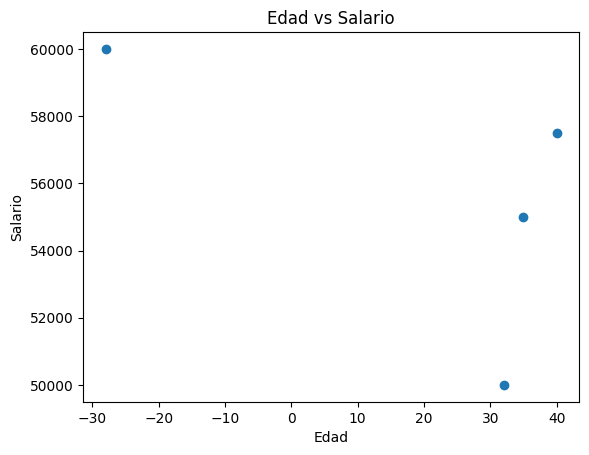

In [6]:
# 7.1 Histograma de salarios
plt.figure()
plt.hist(df["Salario"])
plt.title("Distribución de Salarios")
plt.xlabel("Salario")
plt.ylabel("Frecuencia")
plt.show()

# 7.2 Relación Edad vs Salario
plt.figure()
plt.scatter(df["Edad"], df["Salario"])
plt.title("Edad vs Salario")
plt.xlabel("Edad")
plt.ylabel("Salario")
plt.show()


# =============================
# 8. USO DE LLM (EJEMPLO)
# =============================
# Prompt utilizado:
# "¿Cómo detectar y eliminar outliers en Python?"

# Síntesis:
# Los outliers pueden detectarse usando el método IQR o Z-score.
# En este trabajo se utilizó IQR por ser simple y efectivo.
# Luego se eliminaron los valores fuera del rango permitido.


In [7]:
print("\nPROCESO FINALIZADO CORRECTAMENTE")


PROCESO FINALIZADO CORRECTAMENTE


**Markdown**                             

Tipos de datos:
Edad: numérico
Salario: numérico
Nivel educativo: categórico ordinal
Categoría: categórico
Estado: categórico
Interpretación EDA:
Se observa que los salarios están concentrados en valores medios
Existe relación positiva entre edad y salario (a mayor edad, mayor salario en general)


* **Conclusión final**:

“El preprocesamiento permitió mejorar la calidad de los datos, eliminando errores e inconsistencias, lo cual es fundamental para obtener modelos confiables en minería de datos.”
